# 🐾 TP 10 Análisis del dataset de felinos de Argentina 🐾


## Parte 1 – Análisis básico del dataset

In [1]:
import pandas as pd

feli = pd.read_csv("felinos_filtrado.csv")

### 1. Carga y exploración inicial
Se carga el dataset y se muestran las primeras filas, junto con la cantidad de filas y columnas.

In [2]:
feli.head(3)

,Unnamed: 0,kingdom,phylum,class,order,family,genus,species,locality,stateProvince,lat,lng,elevation,day,month,year,taxonKey,ScientificName,VernacularNames
0,0,Animalia,Chordata,Mammalia,Carnivora,Felidae,Puma,Puma yagouaroundi,<p>Camino acceso al Destacamento Estero Poi</p>,Formosa,-25.12069,-58.18679,0.0,19.0,9.0,2006.0,2435146,Puma yagouaroundi,Jaguarondi Jaguarundi Yaguarundi
1,1,Animalia,Chordata,Mammalia,Carnivora,Felidae,Puma,Puma yagouaroundi,<p>Destacamento de Laguna Blanca</p>,Formosa,-25.17201,-58.13073,0.0,20.0,9.0,2006.0,2435146,Puma yagouaroundi,Jaguarondi Jaguarundi Yaguarundi
2,2,Animalia,Chordata,Mammalia,Carnivora,Felidae,Puma,Puma yagouaroundi,<p>P.N. El Palmar.</p>,Entre Ríos,-31.88614,-58.30839,24.0,8.0,9.0,2006.0,2435146,Puma yagouaroundi,Jaguarondi Jaguarundi Yaguarundi


In [1]:
feli.shape

(2019, 19)

**Comentario:** el dataset tiene **2019 filas y 19 columnas**. 

### 2. Estructura y tipos de datos

In [1]:
feli.dtypes

Unnamed: 0           int64
kingdom                str
phylum                 str
class                  str
order                  str
family                 str
genus                  str
species                str
locality               str
stateProvince          str
lat                float64
lng                float64
elevation          float64
day                float64
month              float64
year               float64
taxonKey             int64
ScientificName         str
VernacularNames        str

### 3. Valores nulos

In [1]:
feli.isnull().sum()

Unnamed: 0          0
kingdom             0
phylum              0
class               0
order               0
family              0
genus               0
species             0
locality            8
stateProvince       8
lat                 0
lng                 0
elevation          21
day                27
month              27
year               27
taxonKey            0
ScientificName      0
VernacularNames     0

## Parte 2 – Preguntas de análisis sobre felinos

In [3]:
import pandas as pd

In [4]:
import plotly.express as px

In [5]:
import folium

In [6]:
feli = pd.read_csv("felinos_filtrado.csv")

### Pregunta 1
¿Cómo cambió la cantidad de avistamientos de felinos durante los últimos meses del año más reciente?

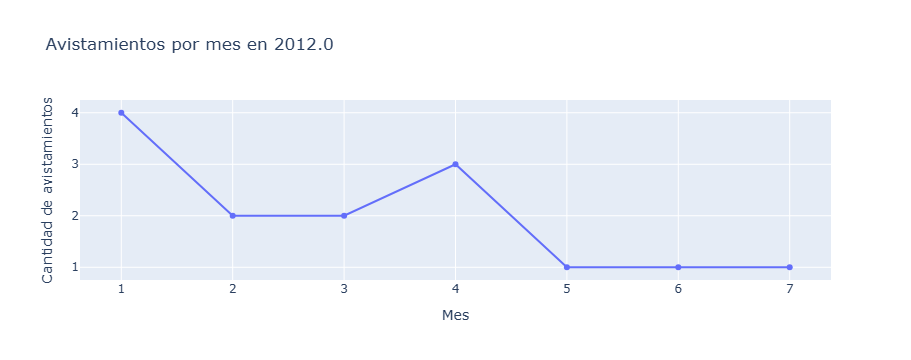

In [7]:
anio_actual = feli["year"].max()
feli_actual = feli[feli["year"] == anio_actual]
meses_actual = feli_actual["month"].value_counts().sort_index()

fig = px.line(
    x=meses_actual.index,
    y=meses_actual.values,
    title=f"Avistamientos por mes en {anio_actual}",
    labels={"x": "Mes", "y": "Cantidad de avistamientos"},
    markers=True
)

fig.show()

### Pregunta 2
¿Cómo cambia la cantidad de avistamientos durante los meses en el año 2010? Mostrar gráfico de líneas.

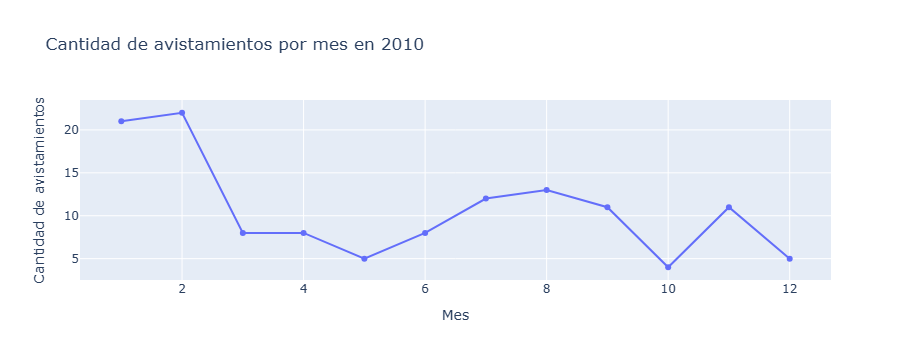

In [8]:
feli_2010 = feli[feli["year"] == 2010]
meses_2010 = feli_2010["month"].value_counts().sort_index()

fig = px.line(
    x=meses_2010.index,
    y=meses_2010.values,
    title="Cantidad de avistamientos por mes en 2010",
    labels={"x": "Mes", "y": "Cantidad de avistamientos"},
    markers=True
)

fig.show()

### Pregunta 3
¿Es verdad que Santa Cruz es la segunda provincia con más avistajes registrados? (Filtro)

In [9]:
provincias = feli["stateProvince"].value_counts()
provincias.head(3)

stateProvince
Misiones      1253
Santa Cruz     313
Corrientes     178
Name: count, dtype: int64

### Pregunta 4
¿Cuántas especies diferentes hay registradas en el archivo? (Cálculo)

In [10]:
feli["species"].nunique()

9

### Pregunta 5
¿En qué meses del año se registraron más avistamientos de felinos? (Gráfico de barras)

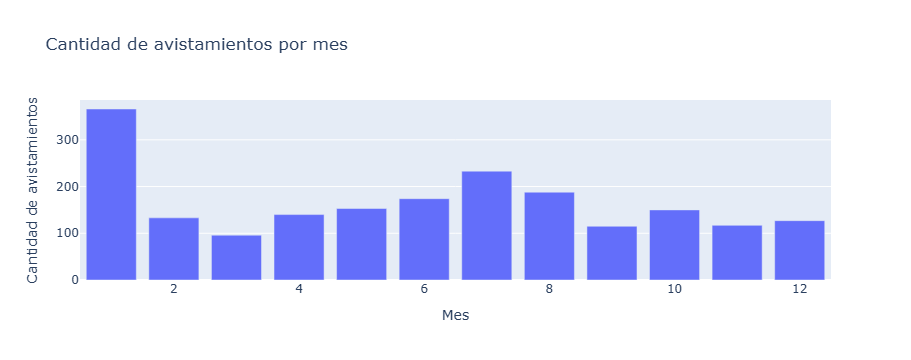

In [11]:
meses = feli["month"].value_counts().sort_index()

fig = px.bar(
    x=meses.index,
    y=meses.values,
    title="Cantidad de avistamientos por mes",
    labels={"x": "Mes", "y": "Cantidad de avistamientos"}
)

fig.show()

### Pregunta 6
¿Qué provincias tienen la mayor cantidad de felinos registrados? (Gráfico de barras)

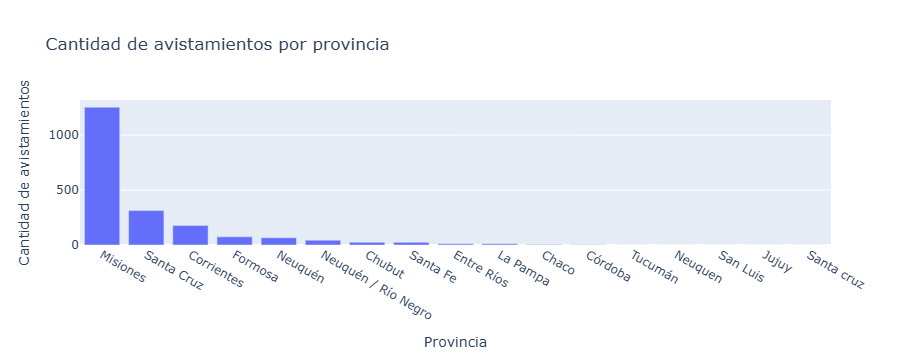

In [12]:
provincias = feli["stateProvince"].value_counts()

fig = px.bar(
    x=provincias.index,
    y=provincias.values,
    title="Cantidad de avistamientos por provincia",
    labels={"x": "Provincia", "y": "Cantidad de avistamientos"}
)

fig.show()

### Pregunta 7
¿Cuáles fueron las 3 especies registradas en las provincias que concentran la mayor cantidad de avistamientos?

In [13]:
feli_top = feli[
    (feli["stateProvince"] == "Misiones") |
    (feli["stateProvince"] == "Santa Cruz") |
    (feli["stateProvince"] == "Corrientes")
]

top_especies = feli_top["species"].value_counts().head(3)

print(top_especies)

species
Puma concolor        1135
Puma yagouaroundi     318
Panthera onca         164
Name: count, dtype: int64


### Pregunta 8
¿Cuál es el mes con mayor y menor porcentaje de avistamientos? (Gráfico de torta)

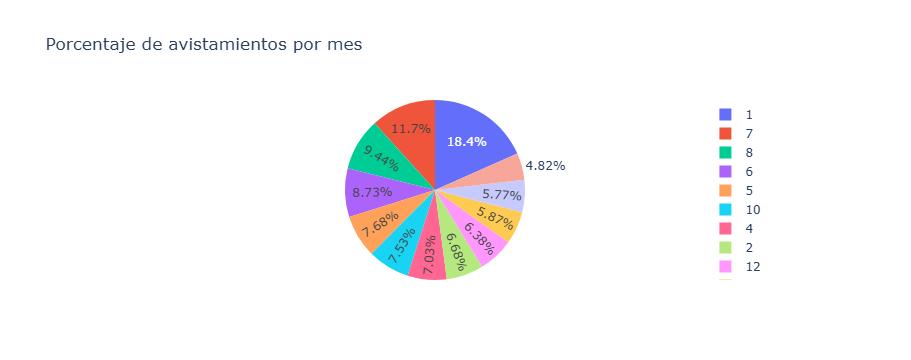

In [14]:
meses = feli["month"].value_counts().sort_index()

porcentajes = meses / meses.sum() * 100

fig = px.pie(
    values=meses.values,
    names=meses.index,
    title="Porcentaje de avistamientos por mes"
)

fig.show()

### Pregunta 9
¿Cómo se distribuyen geográficamente los registros de la especie Panthera onca? (Mapa)

In [15]:
def generar_mapa():

    attr = (
        '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> '
        'contributors, &copy; <a href="https://cartodb.com/attributions">CartoDB</a>'
    )

    tiles = 'https://wms.ign.gob.ar/geoserver/gwc/service/tms/1.0.0/capabaseargenmap@EPSG%3A3857@png/{z}/{x}/{-y}.png'

    m = folium.Map(
        location=(-33.457606, -65.346857),
        control_scale=True,
        zoom_start=5,
        name='es',
        tiles=tiles,
        attr=attr
    )

    return m

In [16]:
# Crear un nuevo mapa
mapa_panthera = generar_mapa()

panthera = feli[
    feli["species"] == "Panthera onca"
]

def agregar_marca_panthera(row):

    folium.Marker(
        [row["lat"], row["lng"]],
        popup=(
            "Especie: " + str(row["species"]) +
            "<br>Provincia: " + str(row["stateProvince"])
        ),
        icon=folium.Icon()
    ).add_to(mapa_panthera)

panthera.apply(
    agregar_marca_panthera,
    axis=1
)

mapa_panthera

### Pregunta 10
Mapa general con todas las especies de "Puma"

In [17]:
mapa = generar_mapa()
pumas = feli[feli["genus"] == "Puma"]

def agregar_marca_puma(row):

    folium.Marker(
        [row["lat"], row["lng"]],
        popup=row["species"],
        icon=folium.Icon()
    ).add_to(mapa)

pumas.apply(agregar_marca_puma, axis=1)

mapa